In [60]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import TypedDict, List, Annotated
from pydantic import Field

In [61]:
class WeightTall(TypedDict):
    weight: int
    tall: int
    bmi: None
    category: str | None

def convert_bmi(state: WeightTall) -> WeightTall:
    tall= state["tall"] / 100
    bmi = state["weight"]/ (tall **2)
    state["bmi"] = bmi
    return state

def label_bmi(state: WeightTall) -> WeightTall:
    bmi = state["bmi"]
    if bmi > 18:
        state["category"] = "Good!" 
    else:
        state["category"] = "Bad"
    return state


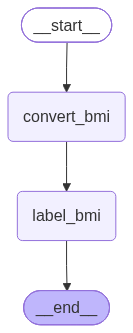

In [62]:
graph_builder = StateGraph(WeightTall)

graph_builder.add_node("convert_bmi", convert_bmi)
graph_builder.add_node("label_bmi", label_bmi)

graph_builder.add_edge(START, "convert_bmi")
graph_builder.add_edge("convert_bmi", "label_bmi")
graph_builder.add_edge("label_bmi", END)

graph = graph_builder.compile()
graph

In [63]:
initial_state = {
    "weight" : 57,
    "tall"  : 172
}

response = graph.invoke(initial_state)
response

{'weight': 57, 'tall': 172, 'bmi': 19.2671714440238, 'category': 'Good!'}